# Crop Disease Detection — Cocoa & Maize (YOLOv11)

**Project:** Group computer vision project detecting crop diseases in cocoa and maize for farmers. The model is then integrated with a RAG that outputs recommendations in the event of diseases in both English and Hausa.

**Objective:** Fine-tune a YOLOv11 object detector on merged, harmonized datasets so a single model can detect 5 diseases on cocoa crop and maize leaf from a single photo.

**Approach:**
1. Pull datatsets with over 3,000 images for cocoa and maize from Roboflow.
2. Rename classes to fit and merge the datasets.
3. Check for class imbalance and inspect random sample annotations of datatset.
4. Apply Augmentation to increase dataset and also correct class imbalance.
5. Train YOLOv11 on the augmented and merged dataset.
6. Evaluate the model nd get the metrics of performance after 100 Epochs

**Environment:** Google Colab, Ultralytics YOLO, Roboflow, Albumentations for augmentation.


## 1. Setup & Dependencies

Install and import the libraries used throughout the pipeline: ultralytics (YOLO), roboflow (dataset access), and albumentations (augmentation).

In [ ]:
!pip install ultralytics roboflow -q
!pip install -q albumentations opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os, glob, shutil
from IPython.display import Video, display
import yaml
from pathlib import Path
from roboflow import Roboflow
import albumentations as A
import cv2
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import argparse
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Mount Google Drive so the trained weights remain across Colab session hits limit.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DIR = '/content/drive/MyDrive/crop_disease_yolo_new'
os.makedirs(DIR, exist_ok=True)
print("Folder ready at:", DIR)

Mounted at /content/drive
Folder ready at: /content/drive/MyDrive/crop_disease_yolo_new


## 2. Data Gathering

Download the annotated datasets from Roboflow in YOLOv11 format:
- **Dataset 1:** Cocoa disease detection (black pod, frosty pod, healthy, mirid damage)
- **Dataset 2:** Maize leaf disease detection (common rust, gray leaf spot, healthy)



In [ ]:
from roboflow import Roboflow
rf1 = Roboflow(api_key="A4wJQFrltZIlWead3fYR")
project1 = rf1.workspace("miss-nyarko-s2gtm").project("cocoa-disease-detection")
version1 = project1.version(3)
dataset1 = version1.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to COCOA-DISEASE-DETECTION-3 in yolov11:: 100%|██████████| 6030/6030 [00:01<00:00, 5943.08it/s]


In [ ]:
rf2 = Roboflow(api_key="A4wJQFrltZIlWead3fYR")
project2 = rf2.workspace("project-ibj2c").project("maize-leaf-disease-detection-ceskb")
version2 = project2.version(3)
dataset2 = version2.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Maize-leaf-disease-detection-3 in yolov11:: 100%|██████████| 6096/6096 [00:01<00:00, 5352.00it/s]


## 3. Data Preparation — Class Harmonization & Merge

Each Roboflow dataset ships with its own data.yaml and class list. Before merging, class names are standardized and re-indexed into one shared label space so a single model can be trained across both crops.

**Steps:**
1. Load each dataset's class list.
2. Rename classes for clarity and consistency.
3. Build an old-ID to new-ID mapping between the two label spaces.
4. Copy images into a merged dataset folder and remap YOLO label files accordingly.
5. Then write a single merged data.yaml.


In [ ]:
dataset1 = "/content/COCOA-DISEASE-DETECTION-3"
dataset2 = "/content/Maize-leaf-disease-detection-3"

output = "/content/merged_dataset"

with open(os.path.join(dataset1, "data.yaml")) as f:
    yaml1 = yaml.safe_load(f)

with open(os.path.join(dataset2, "data.yaml")) as f:
    yaml2 = yaml.safe_load(f)

classes1 = yaml1["names"]
classes2 = yaml2["names"]

In [ ]:
print(classes1)
print(classes2)

['BLACKPOD', 'FROSTYPOD', 'HEALTHY', 'MIRID']
['Common_rust', 'Gray_leaf_spot', 'healthy']


In [ ]:
data1_cfg = os.path.join(dataset1, "data.yaml")
with open(data1_cfg) as f:
    yaml1 = yaml.safe_load(f)

print(yaml.dump(yaml1, sort_keys=False))

train: ../train/images
val: ../valid/images
test: ../test/images
nc: 4
names:
- BLACKPOD
- FROSTYPOD
- HEALTHY
- MIRID
roboflow:
  workspace: miss-nyarko-s2gtm
  project: cocoa-disease-detection
  version: 3
  license: MIT
  url: https://universe.roboflow.com/miss-nyarko-s2gtm/cocoa-disease-detection/dataset/3



In [ ]:
with open(data1_cfg, "r") as f:
    yaml1 = yaml.safe_load(f)

print("Before:", yaml1["names"])

yaml1["names"] = ["Cocoa BlackPod", "Cocoa FrostyPod", "Cocoa Healthy", "Cocoa Mirid"]

with open(data1_cfg, "w") as f:
    yaml.dump(yaml1, f, sort_keys=False)

print("After:", yaml1["names"])

Before: ['BLACKPOD', 'FROSTYPOD', 'HEALTHY', 'MIRID']
After: ['Cocoa BlackPod', 'Cocoa FrostyPod', 'Cocoa Healthy', 'Cocoa Mirid']


In [ ]:
data2_cfg = os.path.join(dataset2, "data.yaml")
with open(data2_cfg) as f:
    yaml2 = yaml.safe_load(f)

print(yaml.dump(yaml2, sort_keys=False))


train: ../train/images
val: ../valid/images
test: ../test/images
nc: 3
names:
- Common_rust
- Gray_leaf_spot
- healthy
roboflow:
  workspace: project-ibj2c
  project: maize-leaf-disease-detection-ceskb
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/project-ibj2c/maize-leaf-disease-detection-ceskb/dataset/3



In [ ]:
with open(data2_cfg, "r") as f:
    yaml2 = yaml.safe_load(f)

print("Before:", yaml2["names"])

yaml2["names"] = ["Maize Common Rust", "Maize Gray Leaf Spot", "Maize Healthy"]

with open(data2_cfg, "w") as f:
    yaml.dump(yaml2, f, sort_keys=False)

print("After:", yaml2["names"])

Before: ['Common_rust', 'Gray_leaf_spot', 'healthy']
After: ['Maize Common Rust', 'Maize Gray Leaf Spot', 'Maize Healthy']


In [ ]:
classes1 = yaml1["names"]
classes2 = yaml2["names"]

In [ ]:
print(classes1)
print(classes2)

['Cocoa BlackPod', 'Cocoa FrostyPod', 'Cocoa Healthy', 'Cocoa Mirid']
['Maize Common Rust', 'Maize Gray Leaf Spot', 'Maize Healthy']


In [ ]:
merged_classes = classes1.copy()

mapping = {}

for old_id, cls in enumerate(classes2):
    if cls in merged_classes:
        mapping[old_id] = merged_classes.index(cls)

    else:
        merged_classes.append(cls)
        mapping[old_id] = len(merged_classes)-1

print(mapping)
print(merged_classes)


for split in ["train","valid","test"]:
    os.makedirs(f"{output}/{split}/images", exist_ok=True)
    os.makedirs(f"{output}/{split}/labels", exist_ok=True)

{0: 4, 1: 5, 2: 6}
['Cocoa BlackPod', 'Cocoa FrostyPod', 'Cocoa Healthy', 'Cocoa Mirid', 'Maize Common Rust', 'Maize Gray Leaf Spot', 'Maize Healthy']


Copied dataset 1 (cocoa) images/labels into the merged dataset structure.

In [ ]:
for split in ["train","valid","test"]:
    image_dir = Path(dataset1)/split/"images"
    label_dir = Path(dataset1)/split/"labels"

    for img in image_dir.iterdir():
        shutil.copy(img, Path(output)/split/"images"/("d1_"+img.name))

    for txt in label_dir.iterdir():
        shutil.copy(txt, Path(output)/split/"labels"/("d1_"+txt.name))

Copied dataset 2 (maize) images/labels into the merged structure, remapping each label's class ID through the mapping built above.

In [ ]:
for split in ["train","valid","test"]:

    image_dir = Path(dataset2)/split/"images"
    label_dir = Path(dataset2)/split/"labels"

    # Copy images
    for img in image_dir.iterdir():
        shutil.copy(img,
                    Path(output)/split/"images"/("d2_"+img.name))
    # Remap labels
    for txt in label_dir.iterdir():
        new_lines = []
        with open(txt) as f:
            lines = f.readlines()
        for line in lines:
            values = line.strip().split()
            class_id = int(values[0])
            values[0] = str(mapping[class_id])
            new_lines.append(" ".join(values))
        with open(Path(output)/split/"labels"/("d2_"+txt.name),"w") as f:
            f.write("\n".join(new_lines))

Then a new data.yaml file was written to accomodate the changes and merging.

In [ ]:
merged_yaml = {
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(merged_classes),
    "names": merged_classes
}

with open(f"{output}/data.yaml","w") as f:
    yaml.dump(merged_yaml,f)

Confirms image/label counts line up per split, and inspect the merged class list.

In [ ]:
for split in ["train", "valid", "test"]:
    imgs = len(list(Path(f"/content/merged_dataset/{split}/images").glob("*")))
    labels = len(list(Path(f"/content/merged_dataset/{split}/labels").glob("*.txt")))
    print(f"{split}: {imgs} images, {labels} labels")

train: 4226 images, 4226 labels
valid: 1196 images, 1196 labels
test: 629 images, 629 labels


The number of images and labels match, therefore no need to clean data for errors that could arise from label and image number mismatch

In [ ]:
classes = merged_yaml['names']
print(classes)

['Cocoa BlackPod', 'Cocoa FrostyPod', 'Cocoa Healthy', 'Cocoa Mirid', 'Maize Common Rust', 'Maize Gray Leaf Spot', 'Maize Healthy']


In [ ]:
data_yaml_path = os.path.join("/content/merged_dataset", "data.yaml")

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

print(yaml.dump(data_cfg, sort_keys=False))

names:
- Cocoa BlackPod
- Cocoa FrostyPod
- Cocoa Healthy
- Cocoa Mirid
- Maize Common Rust
- Maize Gray Leaf Spot
- Maize Healthy
nc: 7
test: test/images
train: train/images
val: valid/images



An inspection was done to how the new yaml file created will look like and it appears as desired.

## 4. Exploratory Data Analysis

Visualize a sample training image with its YOLO-format bounding boxes drawn and labeled, to confirm the merged annotations are correctly aligned after the copy operation performed above.

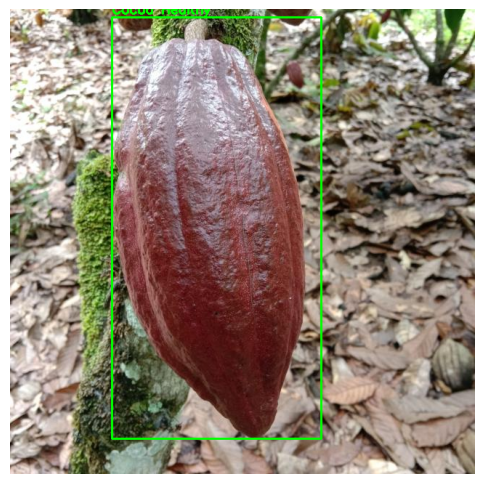

In [ ]:
import cv2
import matplotlib.pyplot as plt

train_img_dir = os.path.join("/content/merged_dataset", "train", "images")
train_lbl_dir = os.path.join("/content/merged_dataset", "train", "labels")

sample_img = sorted(glob.glob(train_img_dir + "/*.jpg"))[3]
sample_lbl = os.path.join(train_lbl_dir, os.path.basename(sample_img).replace(".jpg", ".txt"))

img = cv2.imread(sample_img)
h, w = img.shape[:2]

with open(sample_lbl) as f:
    for line in f:
        cls, xc, yc, bw, bh = map(float, line.split())
        x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
        x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, merged_yaml['names'][int(cls)], (x1, max(y1-5,0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

plt.figure(figsize=(6,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

The image shows a healthy cocoa sample and the bounding box from the merged dataset path, showing the moving worked.

## 5. Data Augmentation

Class imbalance across the merged dataset is addressed with class-aware augmentation, thereby a multiplier was used to check just how many augmenting should be done per classes

Flowline
- Augmentation transforms: horizontal flip, brightness/contrast, rotation, scale, Gaussian blur/noise, random shadow, and hue/saturation/value shifts — applied with bounding-box-aware Albumentations so labels stay correct.
- Per-class multipliers: images containing rarer classes are augmented more times than images of well-represented classes.
- Every original image is preserved alongside its augmented copies.


In [ ]:
transform = A.Compose([
  A.HorizontalFlip(p=0.5),
  A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
  A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5),
  A.RandomScale(scale_limit=0.15, p=0.4),
  A.GaussianBlur(blur_limit=(3, 5), p=0.2),
  A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
  A.RandomShadow(p=0.2),
  A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.5))

These conditions were chosen as the model is to work at real time and given the farmer can take the pictures at random time of the day.
- The horizontal flip for situtaions of landscape camera position.

- The Rotate in the event of angle bending

- The Scale for random zoom

- The Blur for various camera conditions

- The Noise for different camera specs

- The Random shadow in the event leaves cause shadow when taking the picture

In [ ]:
def read_yolo_label(label_path):
    boxes, labels = [], []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, xc, yc, w, h = parts
                    boxes.append([float(xc), float(yc), float(w), float(h)])
                    labels.append(int(cls))
    return boxes, labels

def write_yolo_label(label_path, boxes, labels):
    with open(label_path, 'w') as f:
        for box, cls in zip(boxes, labels):
            f.write(f"{cls} {' '.join(f'{v:.6f}' for v in box)}\n")

In [ ]:
def get_class_counts(labels_dir):
    counts = Counter()
    for label_path in glob.glob(os.path.join(labels_dir, '*.txt')):
        _, labels = read_yolo_label(label_path)
        counts.update(labels)
    return counts

def compute_aug_multipliers(class_counts, base_n=2, max_n=6):
    """More augmentations for underrepresented classes."""
    if not class_counts:
        return {}
    max_count = max(class_counts.values())
    multipliers = {}
    for cls, count in class_counts.items():
        ratio = max_count / count
        n = int(min(max_n, max(base_n, base_n * ratio)))
        multipliers[cls] = n
    return multipliers

def get_image_aug_count(labels, class_multipliers, default_n=2):
    """An image gets augmented as many times as its rarest class needs."""
    if not labels:
        return default_n
    return max(class_multipliers.get(cls, default_n) for cls in labels)


In [ ]:
def augment_dataset(images_dir, labels_dir, out_images_dir, out_labels_dir,
                     base_n=2, max_n=6):
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_labels_dir, exist_ok=True)

    class_counts = get_class_counts(labels_dir)
    class_multipliers = compute_aug_multipliers(class_counts, base_n, max_n)

    print("Class counts:", dict(class_counts))
    print("Aug multipliers per class:", class_multipliers)

    image_paths = glob.glob(os.path.join(images_dir, '*.jpg')) + \
                  glob.glob(os.path.join(images_dir, '*.png')) + \
                  glob.glob(os.path.join(images_dir, '*.jpeg'))

    total_written = 0
    for img_path in image_paths:
        fname = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(labels_dir, fname + '.txt')

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        boxes, labels = read_yolo_label(label_path)

        # always keep the original
        cv2.imwrite(os.path.join(out_images_dir, f"{fname}.jpg"), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        write_yolo_label(os.path.join(out_labels_dir, f"{fname}.txt"), boxes, labels)
        total_written += 1

        n_aug = get_image_aug_count(labels, class_multipliers, default_n=base_n)

        for i in range(n_aug):
            try:
                augmented = transform(image=image, bboxes=boxes, class_labels=labels)
            except Exception as e:
                print(f"Skipped {fname} aug {i}: {e}")
                continue

            aug_boxes = augmented['bboxes']
            aug_labels = augmented['class_labels']
            if len(aug_boxes) == 0:
                continue  # all boxes lost to crop/rotate — skip this augmentation

            aug_img = cv2.cvtColor(augmented['image'], cv2.COLOR_RGB2BGR)
            out_name = f"{fname}_aug{i}"
            cv2.imwrite(os.path.join(out_images_dir, f"{out_name}.jpg"), aug_img)
            write_yolo_label(os.path.join(out_labels_dir, f"{out_name}.txt"), aug_boxes, aug_labels)
            total_written += 1

    print(f"Done. {total_written} images written to {out_images_dir}")

Run the augmentation pass over the training split only (validation/test stay untouched to avoid data leakage).

In [ ]:
augment_dataset(
    images_dir='/content/merged_dataset/train/images',
    labels_dir='/content/merged_dataset/train/labels',
    out_images_dir='/content/dataset_aug/train/images',
    out_labels_dir='/content/dataset_aug/train/labels',
    base_n=2,   # minimum augmentations per image
    max_n=6     # max for very rare classes
)

Class counts: {3: 749, 0: 721, 2: 897, 4: 1600, 1: 280, 5: 311, 6: 562}
Aug multipliers per class: {3: 4, 0: 4, 2: 3, 4: 2, 1: 6, 5: 6, 6: 5}
Done. 19398 images written to /content/dataset_aug/train/images


The augmentation gets done and the image has 19k+ images for training, thr original images are also included in the new train dataset.

Point data.yaml's train path to the augmented image folder as it is the new train dataset, while val and test continue to point at the original splits.

In [ ]:
yaml_path = '/content/merged_dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

data_cfg['train'] = '/content/dataset_aug/train/images'
# val and test stay pointing at the original unaugmented folders
data_cfg['val'] = '/content/merged_dataset/valid/images'
data_cfg['test'] = '/content/merged_dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.safe_dump(data_cfg, f)

with open(yaml_path) as f:
    print(yaml.safe_load(f))

{'names': ['Cocoa BlackPod', 'Cocoa FrostyPod', 'Cocoa Healthy', 'Cocoa Mirid', 'Maize Common Rust', 'Maize Gray Leaf Spot', 'Maize Healthy'], 'nc': 7, 'test': '/content/merged_dataset/test/images', 'train': '/content/dataset_aug/train/images', 'val': '/content/merged_dataset/valid/images'}


In [ ]:
data_yaml_path = os.path.join("/content/merged_dataset", "data.yaml")

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

print(yaml.dump(data_cfg, sort_keys=False))

names:
- Cocoa BlackPod
- Cocoa FrostyPod
- Cocoa Healthy
- Cocoa Mirid
- Maize Common Rust
- Maize Gray Leaf Spot
- Maize Healthy
nc: 7
test: /content/merged_dataset/test/images
train: /content/dataset_aug/train/images
val: /content/merged_dataset/valid/images



Visual spot-check: compare an original image against one augmented version, boxes overlaid, to confirm bounding boxes still line up post-transform.

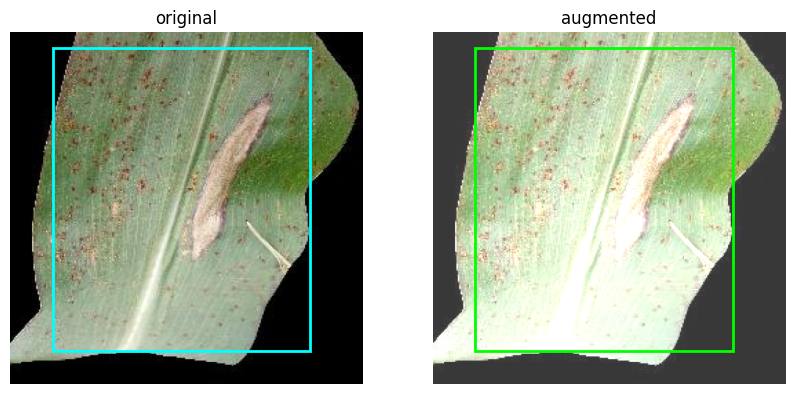

In [ ]:
def show_boxes(image, boxes, ax, color='lime'):
    h, w = image.shape[:2]
    ax.imshow(image)
    for xc, yc, bw, bh in boxes:
        x1, y1 = (xc - bw/2) * w, (yc - bh/2) * h
        ax.add_patch(patches.Rectangle((x1, y1), bw*w, bh*h, edgecolor=color, facecolor='none', linewidth=2))
    ax.axis('off')

# pick a random sample and compare original vs augmented
img_path = random.choice(glob.glob('/content/merged_dataset/train/images/*.jpg'))
label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
boxes, labels = read_yolo_label(label_path)
augmented = transform(image=image, bboxes=boxes, class_labels=labels)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
show_boxes(image, boxes, ax[0], 'cyan'); ax[0].set_title('original')
show_boxes(augmented['image'], augmented['bboxes'], ax[1], 'lime'); ax[1].set_title('augmented')
plt.show()

## 6. Model Training (YOLOv11)

Fine-tune a YOLOv11 model on the merged, augmented dataset.


Reference training configuration (currently commented out) — epochs, image size, batch size, early-stopping patience, checkpoint cadence, and augmentation hyperparameters passed directly to Ultralytics' trainer.

In [ ]:
# from ultralytics import YOLO

# model = YOLO("yolo11s.pt")

# model = model.train(
#     data='/content/merged_dataset/data.yaml',
#     epochs=100,
#     imgsz=640,
#     batch=16,
#     patience=20,                              # early stop if no val improvement for 20 epochs
#     save=True,
#     save_period=10,                           # keep an epoch checkpoint every 10 epochs
#     project='/content/drive/MyDrive/crop_disease_detection_project/runs',
#     name='cocoa_maize_yam_yolo11s_v1',
#     exist_ok=True,                            # avoid auto-incrementing run folder on rerun
#     workers=8,
#     seed=42,                                  # reproducibility across group runs
#     verbose=True,
#     mosaic=0.5,
#     copy_paste=0.3,
#     flipud=0.1,
#     erasing=0.4,
# )


> **Note: the cell below resumes training from a checkpoint, this was done as the colab limit elapses and to allow for continuity from the last.pt file stored in the google drive.


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/crop_disease_detection_project/runs/cocoa_maize_yam_yolo11s_v1/weights/last.pt')
model.train(resume=True)

Ultralytics 8.4.109 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/crop_disease_detection_project/runs/cocoa_maize_yam_yolo11s_v1/weig

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78cf5db1f8f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

## 7. Evaluation

Run validation metrics (precision, recall, mAP@50, mAP@50-95) on the held-out validation/test split.

In [ ]:
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/crop_disease_detection_project/runs/cocoa_maize_yam_yolo11s_v1/weights/best.pt')

metrics = model.val(data='/content/merged_dataset/data.yaml', split='val')  # or split='val'

print(metrics.box.map)      # mAP@50-95
print(metrics.box.map50)    # mAP@50
print(metrics.box.map75)    # mAP@75
print(metrics.box.mp)       # mean precision
print(metrics.box.mr)       # mean recall

# per-class breakdown
for i, cls_name in enumerate(model.names.values()):
    print(cls_name, "AP50:", metrics.box.ap50[i])

Ultralytics 8.4.109 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1532.3±408.2 MB/s, size: 71.0 KB)
val: Scanning /content/merged_dataset/valid/labels.cache... 1196 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1196/1196 334.4Mit/s 0.0s
val: /content/merged_dataset/valid/images/d2_Corn_Health-301-_jpg.rf.e8219c2fec120ae2ebd79a1ed03994a3.jpg: 1 duplicate labels removed
val: /content/merged_dataset/valid/images/d2_Corn_Health-302-_jpg.rf.905b924d980546a303dfa75ff6db7f89.jpg: 1 duplicate labels removed
val: /content/merged_dataset/valid/images/d2_Corn_Health-303-_jpg.rf.88f6546721f19da46beabeb868f5f5bc.jpg: 1 duplicate labels removed
val: /content/merged_dataset/valid/images/d2_Corn_Health-305-_jpg.rf.40c87b73649ae0356f26498d4e4868bb.jpg: 1 duplicate labels removed
val: /content/merged_dataset/valid/images/d2_Corn_Health-306-_jpg.rf.

IndexError: index 6 is out of bounds for axis 0 with size 6

## 8. Export Artifacts

Copy the best model weights and training plots (loss curves, confusion matrix, PR curve) to Google Drive for the project report/submission.

> **Note:** `best_weights` isn't defined earlier in this notebook — set it to the path Ultralytics saved the best checkpoint to, typically `<project>/<name>/weights/best.pt` from the training run above, before running this cell.


In [ ]:
os.makedirs(DIR, exist_ok=True)
best_weights = '/content/drive/MyDrive/crop_disease_detection_project/runs/cocoa_maize_yam_yolo11s_v1/weights/best.pt'

# 1. Model weights
shutil.copy(best_weights, os.path.join(DIR, "best.pt"))

#shutil.copy("/content/runs/detect/val/BoxPR_curve.png", DIR)
# # 2. Training plots (for the report / appendix)
# for fname in ["results.png", "confusion_matrix.png", "BoxPR_curve.png"]:
#     fpath1 = f"/content/runs/detect/val/"
#     if os.path.exists(fpath1):
#         shutil.copy(fpath1, DIR)
fpath = f"/content/runs/detect/val/val_batch2_pred.jpg"
shutil.copy(fpath, DIR)

print("Submission folder contents:")
print(os.listdir(DIR))

Submission folder contents:
['best.pt', 'BoxPR_curve.png', 'confusion_matrix.png', 'val_batch2_pred.jpg']
